# Improved Squat Embedding & Comparison Pipeline

Changes from `check_data_not_normalized.ipynb`:
1. **Fixed symmetry feature indices** (was comparing wrong columns)
2. **Uses 3D angles** instead of 2D (camera-angle robust)
3. **Velocity computed from smoothed angles** (consistent, less noisy)
4. **Added trunk lean angle** (critical for squat form)
5. **Added squat depth feature** (hip height relative to knee)
6. **Rep segmentation** (compare rep-by-rep instead of full video)
7. **Euclidean distance for DTW** (preserves magnitude differences)
8. **Reference-based normalization** (uses pro stats for both videos)
9. **Named feature indices** for interpretability

### Setup & Joint Indices

In [44]:
import os
import sys
import numpy as np
from scipy.signal import savgol_filter, find_peaks
from scipy.spatial.distance import euclidean
from dtw import dtw

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(project_root)

from Utils.utils.utils import calculate_angle_3d

# MediaPipe joint indices
HIP_L = 23
HIP_R = 24
KNEE_L = 25
KNEE_R = 26
ANKLE_L = 27
ANKLE_R = 28
HEEL_L = 29
HEEL_R = 30
TOE_L = 31
TOE_R = 32

SHOULDER_L = 11
SHOULDER_R = 12
ELBOW_L = 13
ELBOW_R = 14
WRIST_L = 15
WRIST_R = 16
PINKY_L = 17
PINKY_R = 18

NOSE = 0

# Feature names for interpretability
ANGLE_NAMES = [
    "left_ankle", "right_ankle",
    "left_knee", "right_knee",
    "left_hip", "right_hip",
    "left_shoulder", "right_shoulder",
    "left_elbow", "right_elbow",
    "left_wrist", "right_wrist",
    "trunk_lean",
]

print("Setup complete.")

Setup complete.


### Load Data

In [45]:
# Load both videos
ref_path = "../MediaPipe_landmarks/front_narrow_landmarks.npy"  # reference / pro
user_path = "../MediaPipe_landmarks/front_wide_landmarks.npy"   # user video

ref_landmarks = np.load(ref_path)
user_landmarks = np.load(user_path)

print(f"Reference: {ref_landmarks.shape}  (frames, joints, xyz)")
print(f"User:      {user_landmarks.shape}")

Reference: (414, 33, 3)  (frames, joints, xyz)
User:      (303, 33, 3)


### Compute Angle Features (3D)

Uses `calculate_angle_3d` instead of `calculate_angle` so the z-coordinate is not discarded.
Also adds trunk lean angle: the angle between the torso vector (pelvis->neck) and vertical.

In [46]:
def compute_trunk_lean(landmarks):
    """
    Compute trunk lean angle relative to vertical for each frame.
    0 = perfectly upright, higher = more forward lean.
    """
    pelvis = (landmarks[:, HIP_L, :] + landmarks[:, HIP_R, :]) / 2.0
    neck = (landmarks[:, SHOULDER_L, :] + landmarks[:, SHOULDER_R, :]) / 2.0
    
    torso_vec = neck - pelvis  # (T, 3)
    # In MediaPipe, y-axis points downward, so "up" is negative y
    vertical = np.array([0, -1, 0])
    
    dot = np.einsum('ij,j->i', torso_vec, vertical)
    norms = np.linalg.norm(torso_vec, axis=1) + 1e-8
    cos_angle = np.clip(dot / norms, -1.0, 1.0)
    
    return np.degrees(np.arccos(cos_angle))  # (T,)


def compute_angle_features_3d(landmarks):
    """
    Compute joint angles using all 3 coordinates (x, y, z).
    Returns: (T, 13) array -- 12 joint angles + trunk lean
    """
    T = landmarks.shape[0]
    features = []

    for f in range(T):
        lm = landmarks[f]

        left_ankle    = calculate_angle_3d(lm[KNEE_L],     lm[ANKLE_L],    lm[TOE_L])
        right_ankle   = calculate_angle_3d(lm[KNEE_R],     lm[ANKLE_R],    lm[TOE_R])
        left_knee     = calculate_angle_3d(lm[HIP_L],      lm[KNEE_L],     lm[ANKLE_L])
        right_knee    = calculate_angle_3d(lm[HIP_R],      lm[KNEE_R],     lm[ANKLE_R])
        left_hip      = calculate_angle_3d(lm[SHOULDER_L], lm[HIP_L],      lm[KNEE_L])
        right_hip     = calculate_angle_3d(lm[SHOULDER_R], lm[HIP_R],      lm[KNEE_R])
        left_shoulder = calculate_angle_3d(lm[ELBOW_L],    lm[SHOULDER_L], lm[HIP_L])
        right_shoulder= calculate_angle_3d(lm[ELBOW_R],    lm[SHOULDER_R], lm[HIP_R])
        left_elbow    = calculate_angle_3d(lm[SHOULDER_L], lm[ELBOW_L],    lm[WRIST_L])
        right_elbow   = calculate_angle_3d(lm[SHOULDER_R], lm[ELBOW_R],    lm[WRIST_R])
        left_wrist    = calculate_angle_3d(lm[ELBOW_L],    lm[WRIST_L],    lm[PINKY_L])
        right_wrist   = calculate_angle_3d(lm[ELBOW_R],    lm[WRIST_R],    lm[PINKY_R])

        features.append([
            left_ankle, right_ankle,
            left_knee, right_knee,
            left_hip, right_hip,
            left_shoulder, right_shoulder,
            left_elbow, right_elbow,
            left_wrist, right_wrist,
        ])

    angles = np.array(features)  # (T, 12)
    trunk_lean = compute_trunk_lean(landmarks)  # (T,)
    angles = np.column_stack([angles, trunk_lean])  # (T, 13)

    return angles


ref_angles = compute_angle_features_3d(ref_landmarks)
user_angles = compute_angle_features_3d(user_landmarks)

print(f"Reference angles: {ref_angles.shape}")
print(f"User angles:      {user_angles.shape}")
print(f"Feature order: {ANGLE_NAMES}")

Reference angles: (414, 13)
User angles:      (303, 13)
Feature order: ['left_ankle', 'right_ankle', 'left_knee', 'right_knee', 'left_hip', 'right_hip', 'left_shoulder', 'right_shoulder', 'left_elbow', 'right_elbow', 'left_wrist', 'right_wrist', 'trunk_lean']


### Smooth Angles

In [47]:
def smooth_angles(angles, window=11, polyorder=3):
    """Savitzky-Golay filter. Adjust window to video FPS if needed."""
    # Ensure window doesn't exceed number of frames
    w = min(window, angles.shape[0])
    if w % 2 == 0:
        w -= 1  # must be odd
    return savgol_filter(angles, window_length=w, polyorder=polyorder, axis=0)

ref_smooth = smooth_angles(ref_angles)
user_smooth = smooth_angles(user_angles)

print(f"Smoothed reference: {ref_smooth.shape}")
print(f"Smoothed user:      {user_smooth.shape}")

Smoothed reference: (414, 13)
Smoothed user:      (303, 13)


### Compute Derived Features (from smoothed data)

- **Velocity**: frame-to-frame angle change (from smoothed angles, not raw)
- **Symmetry**: left-right differences (fixed indices)
- **Squat depth**: hip height relative to knee height

In [48]:
def compute_squat_depth(landmarks):
    """
    Hip Y minus Knee Y (normalized by pelvis-neck distance).
    Positive = hips above knees. Negative = hips below knees (deep squat).
    """
    pelvis = (landmarks[:, HIP_L, :] + landmarks[:, HIP_R, :]) / 2.0
    neck = (landmarks[:, SHOULDER_L, :] + landmarks[:, SHOULDER_R, :]) / 2.0
    
    # Scale factor: pelvis-to-neck distance
    scale = np.linalg.norm(neck - pelvis, axis=1, keepdims=True) + 1e-8
    
    hip_y = pelvis[:, 1:2]  # y coordinate of pelvis
    knee_y = ((landmarks[:, KNEE_L, 1:2] + landmarks[:, KNEE_R, 1:2]) / 2.0)
    
    # Normalize by torso length. In MediaPipe y increases downward,
    # so hip_y < knee_y means hips are above knees
    depth = (hip_y - knee_y) / scale  # negative = deeper squat
    return depth  # (T, 1)


def build_embedding(smooth_angles, landmarks):
    """
    Build the full embedding from smoothed angles and raw landmarks.
    All derived features use smoothed angles for consistency.
    
    Returns: (T-1, D) embedding array and list of feature names.
    """
    # Velocity from smoothed angles (T-1 frames)
    velocity = np.diff(smooth_angles, axis=0)
    
    # Trim everything to match velocity length (T-1)
    T = velocity.shape[0]
    angles_trimmed = smooth_angles[:T]
    
    # Symmetry features from smoothed angles (fixed indices!)
    # Index 2 = left_knee, 3 = right_knee, 4 = left_hip, 5 = right_hip
    knee_symmetry = (angles_trimmed[:, 2] - angles_trimmed[:, 3]).reshape(-1, 1)
    hip_symmetry = (angles_trimmed[:, 4] - angles_trimmed[:, 5]).reshape(-1, 1)
    
    # Squat depth
    depth = compute_squat_depth(landmarks)[:T]  # (T, 1)
    
    embedding = np.concatenate([
        angles_trimmed,     # 13 smoothed angles
        velocity,           # 13 velocity features
        knee_symmetry,      # 1
        hip_symmetry,       # 1
        depth,              # 1
    ], axis=1)
    
    # Build feature name list
    feature_names = (
        [f"angle_{n}" for n in ANGLE_NAMES] +
        [f"vel_{n}" for n in ANGLE_NAMES] +
        ["knee_symmetry", "hip_symmetry", "squat_depth"]
    )
    
    return embedding, feature_names


ref_embedding, feature_names = build_embedding(ref_smooth, ref_landmarks)
user_embedding, _ = build_embedding(user_smooth, user_landmarks)

print(f"Reference embedding: {ref_embedding.shape}")
print(f"User embedding:      {user_embedding.shape}")
print(f"Total features: {len(feature_names)}")
print(f"Features: {feature_names}")

Reference embedding: (413, 29)
User embedding:      (302, 29)
Total features: 29
Features: ['angle_left_ankle', 'angle_right_ankle', 'angle_left_knee', 'angle_right_knee', 'angle_left_hip', 'angle_right_hip', 'angle_left_shoulder', 'angle_right_shoulder', 'angle_left_elbow', 'angle_right_elbow', 'angle_left_wrist', 'angle_right_wrist', 'angle_trunk_lean', 'vel_left_ankle', 'vel_right_ankle', 'vel_left_knee', 'vel_right_knee', 'vel_left_hip', 'vel_right_hip', 'vel_left_shoulder', 'vel_right_shoulder', 'vel_left_elbow', 'vel_right_elbow', 'vel_left_wrist', 'vel_right_wrist', 'vel_trunk_lean', 'knee_symmetry', 'hip_symmetry', 'squat_depth']


### Normalize Embeddings

Uses the **reference athlete's** mean/std to normalize both videos.
This preserves real differences in range of motion instead of squashing them.

In [49]:
# Compute stats from reference (pro) video
ref_mean = ref_embedding.mean(axis=0)
ref_std = ref_embedding.std(axis=0) + 1e-8

# Normalize both using the reference stats
ref_norm = (ref_embedding - ref_mean) / ref_std
user_norm = (user_embedding - ref_mean) / ref_std

print(f"Reference normalized: {ref_norm.shape}")
print(f"User normalized:      {user_norm.shape}")
print(f"\nRef mean after normalization (should be ~0):  {ref_norm.mean(axis=0)[:3].round(4)}...")
print(f"User mean after normalization (deviations from pro): {user_norm.mean(axis=0)[:3].round(4)}...")

Reference normalized: (413, 29)
User normalized:      (302, 29)

Ref mean after normalization (should be ~0):  [ 0. -0. -0.]...
User mean after normalization (deviations from pro): [-1.3089 -1.5143 -0.5548]...


### (Optional) Rep Segmentation

Detect individual squat reps by finding minima in knee angle.
This lets you compare rep-by-rep instead of the full video.

Reference video:
  Detected 3 squat bottoms at frames: [ 75 202 320]
  Knee angles at bottoms: ['40.9', '54.6', '76.0']
  Reps detected: 3
    Rep 1: frames 0-138 (138 frames)
    Rep 2: frames 138-261 (123 frames)
    Rep 3: frames 261-413 (152 frames)

User video:
  Detected 3 squat bottoms at frames: [ 34 137 245]
  Knee angles at bottoms: ['35.2', '48.8', '66.6']
  Reps detected: 3
    Rep 1: frames 0-85 (85 frames)
    Rep 2: frames 85-191 (106 frames)
    Rep 3: frames 191-302 (111 frames)


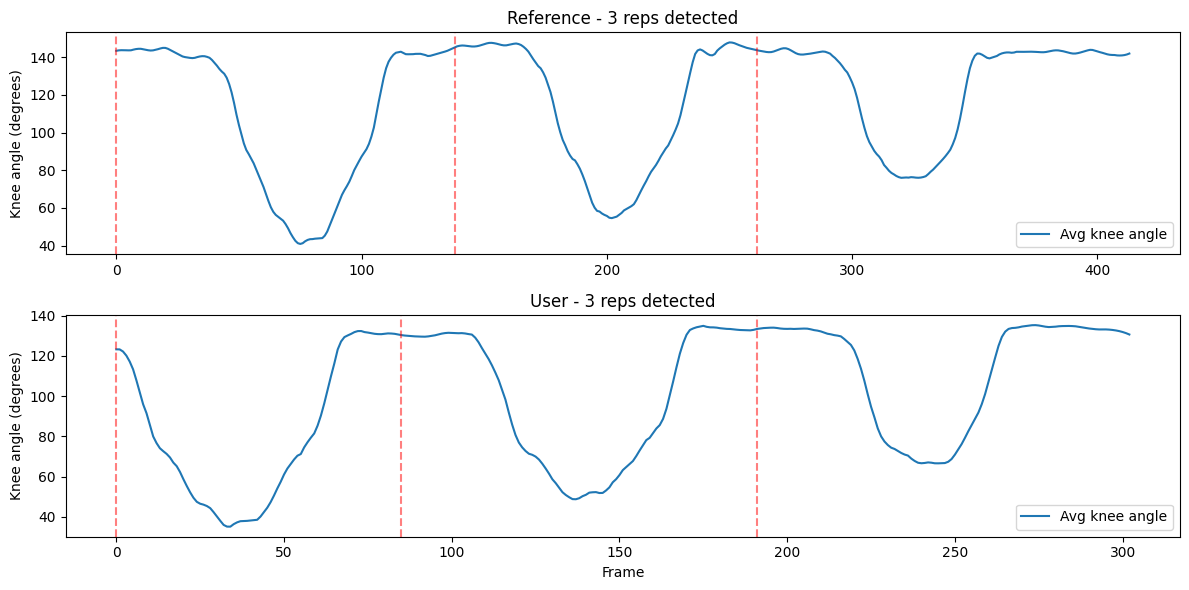

In [50]:
import matplotlib.pyplot as plt

def find_rep_boundaries(smooth_angles, min_distance=100, prominence=25):
    """
    Find squat rep boundaries by detecting knee angle minima (bottom of squat).
    Uses average of left + right knee for a more stable signal.
    
    Args:
        smooth_angles: (T, D) smoothed angle features
        min_distance: minimum frames between rep bottoms (~3-4s at 30fps)
        prominence: minimum angle drop in degrees to count as a real rep
    
    Returns list of (start, end) frame indices for each rep.
    """
    # Average left knee (col 2) and right knee (col 3) for stability
    knee_angle = (smooth_angles[:, 2] + smooth_angles[:, 3]) / 2.0
    
    # Find bottoms (minima) = peaks in inverted signal
    bottoms, properties = find_peaks(-knee_angle, distance=min_distance, prominence=prominence)
    
    print(f"  Detected {len(bottoms)} squat bottoms at frames: {bottoms}")
    print(f"  Knee angles at bottoms: {[f'{knee_angle[b]:.1f}' for b in bottoms]}")
    
    if len(bottoms) < 1:
        print("  WARNING: Could not detect any reps. Using full video.")
        return [(0, len(knee_angle) - 1)], knee_angle
    
    # Split at midpoints between consecutive bottoms
    boundaries = [0]
    for i in range(len(bottoms) - 1):
        mid = (bottoms[i] + bottoms[i+1]) // 2
        boundaries.append(mid)
    boundaries.append(len(knee_angle) - 1)
    
    reps = []
    for i in range(len(boundaries) - 1):
        reps.append((boundaries[i], boundaries[i+1]))
    
    return reps, knee_angle


print("Reference video:")
ref_reps, ref_knee = find_rep_boundaries(ref_smooth)
print(f"  Reps detected: {len(ref_reps)}")
for i, (s, e) in enumerate(ref_reps):
    print(f"    Rep {i+1}: frames {s}-{e} ({e-s} frames)")

print(f"\nUser video:")
user_reps, user_knee = find_rep_boundaries(user_smooth)
print(f"  Reps detected: {len(user_reps)}")
for i, (s, e) in enumerate(user_reps):
    print(f"    Rep {i+1}: frames {s}-{e} ({e-s} frames)")

# Plot knee angle signals so you can visually verify rep detection
fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=False)

axes[0].plot(ref_knee, label="Avg knee angle")
for i, (s, e) in enumerate(ref_reps):
    axes[0].axvline(s, color='r', linestyle='--', alpha=0.5)
axes[0].set_title(f"Reference - {len(ref_reps)} reps detected")
axes[0].set_ylabel("Knee angle (degrees)")
axes[0].legend()

axes[1].plot(user_knee, label="Avg knee angle")
for i, (s, e) in enumerate(user_reps):
    axes[1].axvline(s, color='r', linestyle='--', alpha=0.5)
axes[1].set_title(f"User - {len(user_reps)} reps detected")
axes[1].set_xlabel("Frame")
axes[1].set_ylabel("Knee angle (degrees)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Per-Feature DTW Comparison

Instead of one DTW across all 29 features (where Euclidean distance explodes 
due to curse of dimensionality), we run DTW on each angle independently.

After DTW alignment, we compute **Pearson correlation** between the aligned 
signals. This gives a score in [-1, 1] where:
- **1.0** = identical movement pattern
- **0.0** = unrelated
- **-1.0** = opposite movement

This approach is general -- it works for any exercise without custom rules.

In [51]:
from dtw import dtw

def per_feature_dtw_similarity(ref_angles, user_angles, feature_names):
    """
    Run DTW independently on each feature (1D signal).
    After alignment, compute Pearson correlation and mean absolute error.
    
    Returns dict with per-feature results and overall similarity.
    """
    n_features = ref_angles.shape[1]
    results = []
    
    for i in range(n_features):
        ref_signal = ref_angles[:, i]
        user_signal = user_angles[:, i]
        
        # DTW on 1D signals (absolute difference as distance)
        d, c, a, p = dtw(
            ref_signal.reshape(-1, 1),
            user_signal.reshape(-1, 1),
            dist=lambda x, y: abs(x[0] - y[0])
        )
        
        idx_r, idx_u = p
        
        # Aligned signals
        ref_aligned = ref_signal[idx_r]
        user_aligned = user_signal[idx_u]
        
        # Pearson correlation (pattern similarity)
        correlation = np.corrcoef(ref_aligned, user_aligned)[0, 1]
        
        # Mean absolute error in degrees (magnitude difference)
        mae_degrees = np.mean(np.abs(ref_aligned - user_aligned))
        
        results.append({
            'feature': feature_names[i],
            'correlation': correlation,
            'mae_degrees': mae_degrees,
        })
    
    return results


# Run per-feature comparison on smoothed angles (not the full embedding)
results = per_feature_dtw_similarity(ref_smooth, user_smooth, ANGLE_NAMES)

print(f"{'Feature':<20} {'Correlation':>12} {'MAE (degrees)':>14}")
print("-" * 48)
for r in results:
    print(f"{r['feature']:<20} {r['correlation']:>12.4f} {r['mae_degrees']:>12.1f}")

# Overall similarity: average correlation across all features
correlations = [r['correlation'] for r in results]
overall_similarity = np.mean(correlations)
print(f"\n{'Overall similarity (mean correlation):':<40} {overall_similarity:.4f}")

# Core squat features only (knees, hips, trunk lean)
core_features = ['left_knee', 'right_knee', 'left_hip', 'right_hip', 'trunk_lean']
core_corrs = [r['correlation'] for r in results if r['feature'] in core_features]
core_similarity = np.mean(core_corrs)
print(f"{'Core squat similarity (knee/hip/trunk):':<40} {core_similarity:.4f}")

Feature               Correlation  MAE (degrees)
------------------------------------------------
left_ankle                 0.8363          4.6
right_ankle                0.8137          5.5
left_knee                  0.9887          6.0
right_knee                 0.9862          4.3
left_hip                   0.9946          4.4
right_hip                  0.9981          1.4
left_shoulder              0.9695          5.2
right_shoulder             0.9877          2.7
left_elbow                 0.8831          2.8
right_elbow                0.9497          2.4
left_wrist                 0.9239          0.8
right_wrist                0.9795          0.5
trunk_lean                 0.9701          1.8

Overall similarity (mean correlation):   0.9447
Core squat similarity (knee/hip/trunk):  0.9875


### Per-Rep Comparison

Compare matching reps using the same per-feature DTW approach.

In [52]:
n_reps_to_compare = min(len(ref_reps), len(user_reps))

core_features = ['left_knee', 'right_knee', 'left_hip', 'right_hip', 'trunk_lean']

for i in range(n_reps_to_compare):
    rs, re = ref_reps[i]
    us, ue = user_reps[i]
    
    ref_rep_angles = ref_smooth[rs:re+1]
    user_rep_angles = user_smooth[us:ue+1]
    
    if len(ref_rep_angles) < 5 or len(user_rep_angles) < 5:
        print(f"Rep {i+1}: too short, skipping")
        continue
    
    rep_results = per_feature_dtw_similarity(ref_rep_angles, user_rep_angles, ANGLE_NAMES)
    
    all_corrs = [r['correlation'] for r in rep_results]
    core_corrs = [r['correlation'] for r in rep_results if r['feature'] in core_features]
    
    print(f"Rep {i+1}:")
    print(f"  Overall similarity:    {np.mean(all_corrs):.4f}")
    print(f"  Core squat similarity: {np.mean(core_corrs):.4f}")
    for r in rep_results:
        marker = " ***" if r['feature'] in core_features else ""
        print(f"    {r['feature']:<20} corr={r['correlation']:>7.4f}  MAE={r['mae_degrees']:>6.1f} deg{marker}")
    print()

Rep 1:
  Overall similarity:    0.9497
  Core squat similarity: 0.9921
    left_ankle           corr= 0.8071  MAE=   6.4 deg
    right_ankle          corr= 0.8641  MAE=   6.0 deg
    left_knee            corr= 0.9938  MAE=   6.7 deg ***
    right_knee           corr= 0.9825  MAE=   7.3 deg ***
    left_hip             corr= 0.9977  MAE=   6.1 deg ***
    right_hip            corr= 0.9995  MAE=   1.3 deg ***
    left_shoulder        corr= 0.9767  MAE=   7.7 deg
    right_shoulder       corr= 0.9929  MAE=   2.9 deg
    left_elbow           corr= 0.8796  MAE=   3.5 deg
    right_elbow          corr= 0.9366  MAE=   4.1 deg
    left_wrist           corr= 0.9615  MAE=   0.8 deg
    right_wrist          corr= 0.9674  MAE=   0.8 deg
    trunk_lean           corr= 0.9871  MAE=   1.7 deg ***

Rep 2:
  Overall similarity:    0.9424
  Core squat similarity: 0.9930
    left_ankle           corr= 0.8206  MAE=   5.9 deg
    right_ankle          corr= 0.7525  MAE=   7.0 deg
    left_knee            co

### Visualize Per-Feature Alignment

Plot the DTW-aligned signals for the core squat features to see where the user deviates from the reference.

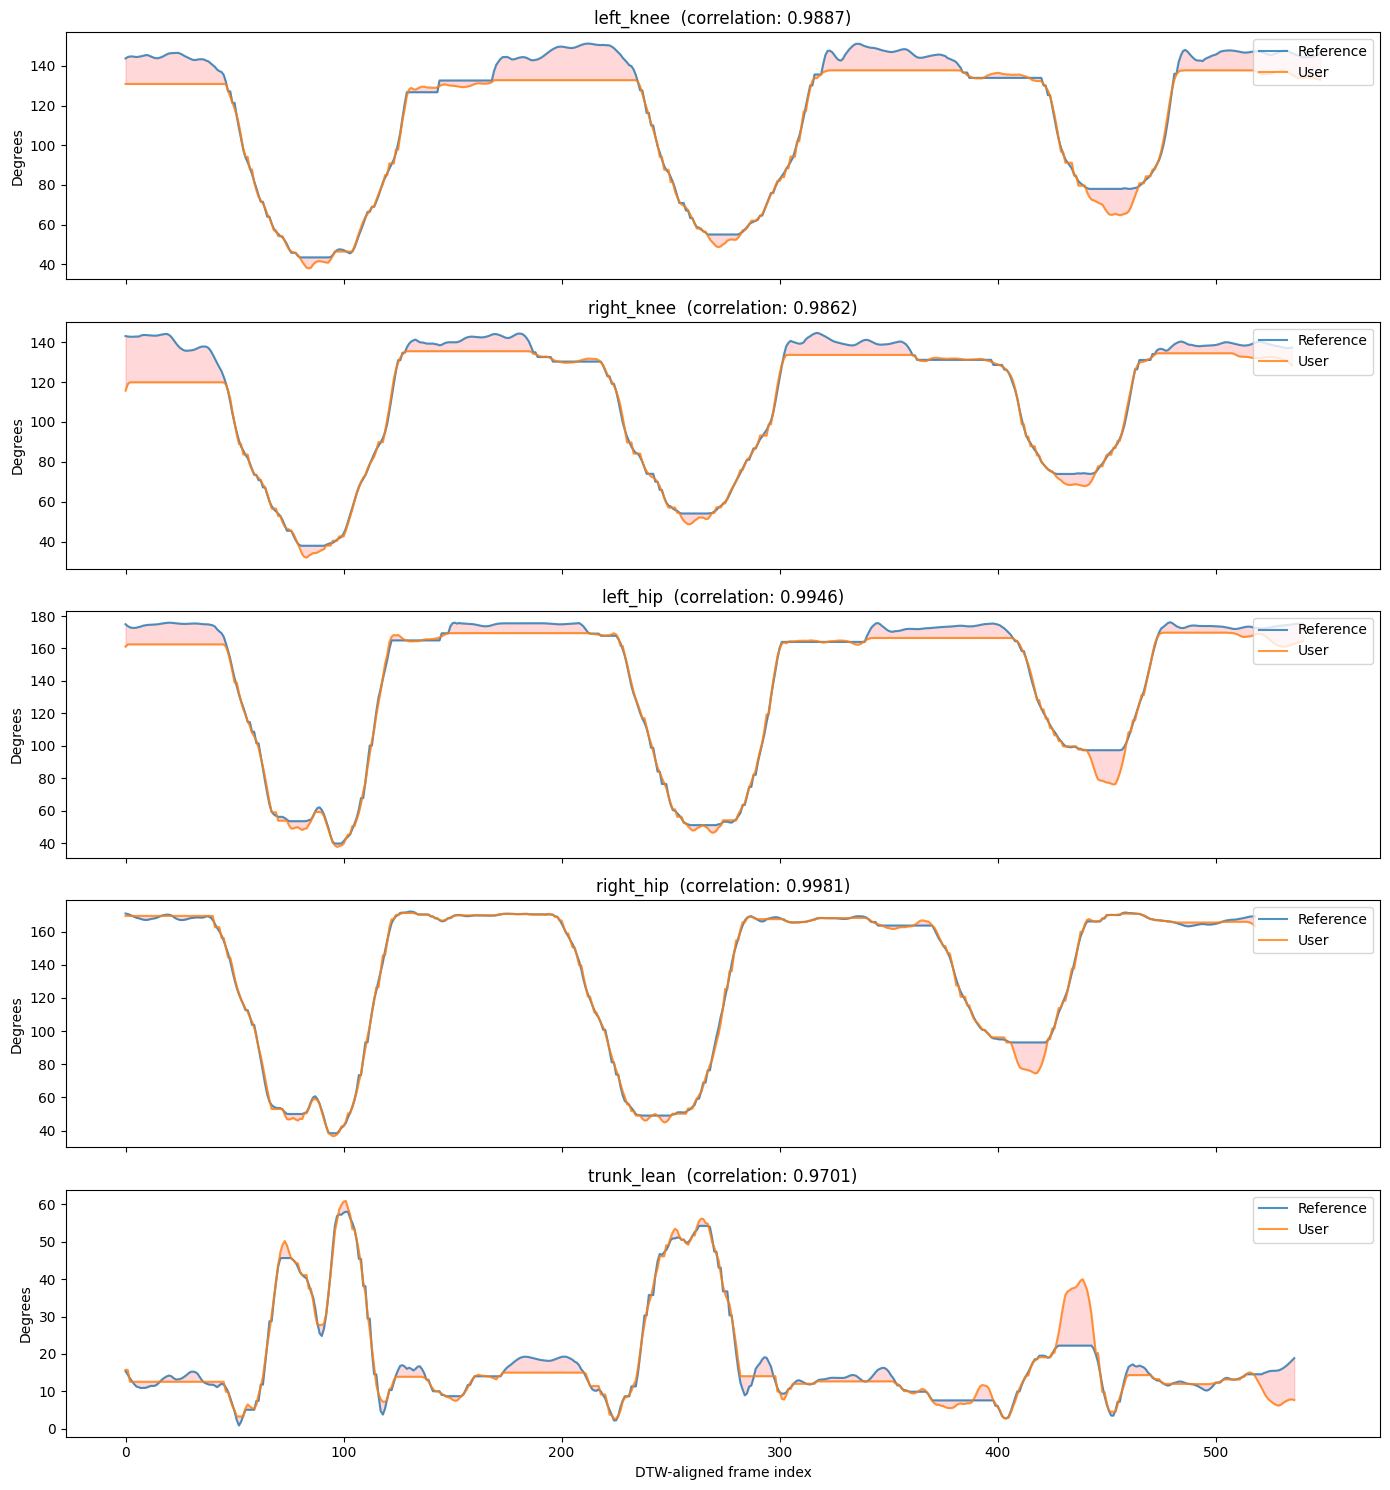

In [53]:
core_indices = [i for i, n in enumerate(ANGLE_NAMES) if n in core_features]

fig, axes = plt.subplots(len(core_indices), 1, figsize=(14, 3 * len(core_indices)), sharex=True)

for ax_idx, feat_idx in enumerate(core_indices):
    ref_signal = ref_smooth[:, feat_idx]
    user_signal = user_smooth[:, feat_idx]
    
    # DTW alignment
    d, c, a, p = dtw(
        ref_signal.reshape(-1, 1),
        user_signal.reshape(-1, 1),
        dist=lambda x, y: abs(x[0] - y[0])
    )
    
    ref_aligned = ref_signal[p[0]]
    user_aligned = user_signal[p[1]]
    corr = np.corrcoef(ref_aligned, user_aligned)[0, 1]
    
    axes[ax_idx].plot(ref_aligned, label='Reference', alpha=0.8)
    axes[ax_idx].plot(user_aligned, label='User', alpha=0.8)
    axes[ax_idx].fill_between(
        range(len(ref_aligned)),
        ref_aligned, user_aligned,
        alpha=0.15, color='red'
    )
    axes[ax_idx].set_ylabel('Degrees')
    axes[ax_idx].set_title(f"{ANGLE_NAMES[feat_idx]}  (correlation: {corr:.4f})")
    axes[ax_idx].legend(loc='upper right')

axes[-1].set_xlabel('DTW-aligned frame index')
plt.tight_layout()
plt.show()

### Per-Feature Error Summary

Which joints have the largest absolute deviation in degrees?

In [54]:
# Sort by MAE (largest deviation first)
sorted_results = sorted(results, key=lambda r: r['mae_degrees'], reverse=True)

print(f"{'Feature':<20} {'Corr':>8} {'MAE (deg)':>10} {'Assessment'}")
print("-" * 60)
for r in sorted_results:
    corr = r['correlation']
    if corr > 0.9:
        assessment = "Excellent"
    elif corr > 0.7:
        assessment = "Good"
    elif corr > 0.5:
        assessment = "Moderate"
    elif corr > 0.3:
        assessment = "Poor"
    else:
        assessment = "Very different"
    
    marker = " <--" if r['feature'] in core_features else ""
    print(f"{r['feature']:<20} {corr:>8.4f} {r['mae_degrees']:>8.1f}   {assessment}{marker}")

Feature                  Corr  MAE (deg) Assessment
------------------------------------------------------------
left_knee              0.9887      6.0   Excellent <--
right_ankle            0.8137      5.5   Good
left_shoulder          0.9695      5.2   Excellent
left_ankle             0.8363      4.6   Good
left_hip               0.9946      4.4   Excellent <--
right_knee             0.9862      4.3   Excellent <--
left_elbow             0.8831      2.8   Good
right_shoulder         0.9877      2.7   Excellent
right_elbow            0.9497      2.4   Excellent
trunk_lean             0.9701      1.8   Excellent <--
right_hip              0.9981      1.4   Excellent <--
left_wrist             0.9239      0.8   Excellent
right_wrist            0.9795      0.5   Excellent


### Save Embeddings

In [55]:
os.makedirs("../embedding", exist_ok=True)

np.save("../embedding/ref_improved_embedding.npy", ref_embedding)
np.save("../embedding/user_improved_embedding.npy", user_embedding)

# Also save the normalization stats so they can be reused in production
np.savez("../embedding/normalization_stats.npz", mean=ref_mean, std=ref_std)

print("Embeddings and normalization stats saved.")

Embeddings and normalization stats saved.


### Why per-feature DTW works better

| Problem with multi-dim DTW | Per-feature DTW solution |
|---|---|
| Euclidean distance in 29D explodes (curse of dimensionality) | Each DTW operates on a 1D signal |
| Noisy features (wrists, elbows) dominate the distance | Each feature gets its own similarity score |
| `exp(-dist)` always near zero in high dimensions | Pearson correlation gives intuitive [-1, 1] range |
| Can't tell *which* joint is the problem | Per-feature breakdown shows exactly where user deviates |
| Single number hides everything | Core feature average focuses on what matters for the exercise |

This approach is **exercise-agnostic**: just change which features are in `core_features` for different exercises (e.g., add shoulders for overhead press).